# Microwave–optical entanglement — analytic 3-wave-mixing model

A clean, closed-form version of the two-mode-squeezing entanglement calculation, as a
readable cross-check on the scattering-matrix code in `src/entanglement.py` and on
S. \[reference notebook\].

Everything is the pure two-mode-squeezing resonance $\Delta' = -\omega_b'$, $g_t = 0$
(no beam-splitter term), all input modes in vacuum, one 100 ns Gaussian temporal mode.

**Bottom line of this notebook:** the two calculations agree on the mode variances and
disagree on *one term* in the microwave–optical correlation — the frequency dependence
of the optical reflection $S_{11}(\omega)$. Keeping it (`full`) vs freezing it at its
DC value (`frozen`, the reference-notebook approximation) is the entire difference
between "$E_N$ saturates for King" and "$E_N\to0$ for both devices".

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

from src import Transducer
from src.entanglement import covariance as covariance_scattering, log_negativity
from src.params import KING_PARAMS, ROCHMAN_PARAMS

TAU = 100.0        # temporal-mode width  [ (2 pi GHz)^-1 ];  1/TAU = 10 MHz bandwidth

## The model

Rotating frame, $\omega$ = offset from the sideband. The resonant subspace is $(a,\,b^\dagger)$
with $H_{\rm eff}/\hbar = -g_s(ab + a^\dagger b^\dagger)$ and squeezing cooperativity
$C = 4g_s^2/(\kappa_a\kappa_b)$ ($C=1$ is the parametric-oscillation threshold).

Define
$$D(\omega) = (i\omega - \tfrac{\kappa_a}{2})(i\omega - \tfrac{\kappa_b}{2}) - g_s^2,
\qquad
\mathrm{denom}(\omega) = \frac{|D(\omega)|^2}{(\kappa_a\kappa_b/4)^2}
= \Big(1 - C - \tfrac{4\omega^2}{\kappa_a\kappa_b}\Big)^2
   + \frac{4\omega^2(\kappa_a+\kappa_b)^2}{(\kappa_a\kappa_b)^2}.$$

The symmetrised output-field spectra (vacuum input) are
$$
n_o(\omega) = \tfrac12 + \frac{4\eta_a C}{\mathrm{denom}(\omega)},\qquad
n_m(\omega) = \tfrac12 + \frac{4\eta_b C}{\mathrm{denom}(\omega)},
$$
$$
S_{om}(\omega) = \sqrt{4\eta_a\eta_b C}\;\frac{N(\omega)}{\mathrm{denom}(\omega)},
\qquad
\boxed{N(\omega) = (1+C) + \frac{4\omega^2}{\kappa_a\kappa_b}}.
$$

The correlation comes from $\langle a_{\rm out}(\omega)\,b_{\rm out}(-\omega)\rangle
= S_{11}(\omega)\,S_{23}(-\omega)$, where the optical **reflection** coefficient is

$$S_{11}(\omega) = -1 - \kappa_a^{\rm ext}\big[(A+i\omega)^{-1}\big]_{11}
= \frac{\omega^2 - i\omega(\kappa_a-\kappa_b)/2 + (\kappa_a\kappa_b/4)(1+C)}{D(\omega)}.$$

At line centre $S_{11}(0) = (1+C)/(1-C)$; it rolls to $-1$ over a width $\sim\sqrt{\kappa_a\kappa_b}/2$.
That roll-off is the $4\omega^2/(\kappa_a\kappa_b)$ piece of $N(\omega)$.

* **`freeze_S11=True`** → $N(\omega)=(1+C)$ (i.e. $S_{11}(\omega)\equiv S_{11}(0)$): the reference-notebook model.
* **`freeze_S11=False`** → full $N(\omega)$: matches `src/entanglement.py` to 4 decimals (checked below).

In [2]:
def covariance_analytic(params, C, tau, freeze_S11=False):
    """
    Filtered two-mode covariance from the closed-form spectra above.
    Basis (q_a, q_b, p_a, p_b), same as src.entanglement.covariance.
    """
    ka, kb = params["kappa_a"], params["kappa_b"]
    ea, eb = params["eta_a"],   params["eta_b"]

    def denom(w):
        return (1 - C - 4*w**2/(ka*kb))**2 + 4*w**2*(ka + kb)**2/(ka**2*kb**2)

    f2 = lambda w: (tau/np.sqrt(np.pi)) * np.exp(-tau**2 * w**2)   # |f(w)|^2, integral = 1
    wmax = 25/tau
    filt = lambda g: quad(lambda w: f2(w)*g(w), -wmax, wmax, limit=400, points=[0])[0]

    N = (lambda w: 1 + C) if freeze_S11 else (lambda w: 1 + C + 4*w**2/(ka*kb))
    d_o = 0.5 + filt(lambda w: 4*ea*C / denom(w))
    d_m = 0.5 + filt(lambda w: 4*eb*C / denom(w))
    s   =       filt(lambda w: np.sqrt(4*ea*eb*C) * N(w) / denom(w))

    return np.array([[d_o,  s,   0,   0  ],
                     [ s,  d_m,  0,   0  ],
                     [ 0,   0,  d_o, -s  ],
                     [ 0,   0,  -s,  d_m ]])

## Log-negativity

For a covariance in standard two-mode form the smaller partial-transpose symplectic
eigenvalue is
$$\tilde\nu_-^2 = \frac{\tilde\Delta - \sqrt{\tilde\Delta^2 - 4\det V}}{2},\qquad
\tilde\Delta = d_o^2 + d_m^2 + 2s^2,\quad \det V = (d_o d_m - s^2)^2,$$
and $E_N = \max[0,\,-\log_2(2\tilde\nu_-)]$. This is identical to
`src.entanglement.log_negativity` (imported above); we use that one so the analytic
and scattering results go through the same estimator.

In [3]:
def EN_standard_form(V):
    d_o, d_m, s = V[0, 0], V[1, 1], V[0, 1]
    Dt   = d_o**2 + d_m**2 + 2*s**2
    detV = (d_o*d_m - s**2)**2
    nu2  = (Dt - np.sqrt(max(Dt**2 - 4*detV, 0.0))) / 2
    return max(0.0, -np.log2(2*np.sqrt(nu2)))

# sanity: the two estimators agree
_V = covariance_analytic({**KING_PARAMS, "eta_a": 1.0, "eta_b": 1.0}, 0.8, TAU)
print(EN_standard_form(_V), log_negativity(_V))

0.5902779165181974 0.5902779165181924


## Cross-check: analytic (full) vs the scattering-matrix code

Ideal out-coupling ($\eta_a=\eta_b=1$), so we isolate the physics from the coupling losses.

In [4]:
print(f"{'device':9s} {'C':>5s}  {'scattering':>10s} {'analytic-full':>13s} {'frozen S11':>11s}")
for name, P in [("King", KING_PARAMS), ("Rochman", ROCHMAN_PARAMS)]:
    p   = {**P, "eta_a": 1.0, "eta_b": 1.0}
    dev = Transducer.from_params(p, Delta=-p["omega_b"])
    for C in (0.5, 0.9, 0.99):
        g_s   = np.sqrt(C * p["kappa_a"] * p["kappa_b"]) / 2
        code  = log_negativity(covariance_scattering(dev, 0.0, g_s, TAU))
        full  = log_negativity(covariance_analytic(p, C, TAU, freeze_S11=False))
        froz  = log_negativity(covariance_analytic(p, C, TAU, freeze_S11=True))
        print(f"{name:9s} {C:5.2f}  {code:10.4f} {full:13.4f} {froz:11.4f}")

device        C  scattering analytic-full  frozen S11
King       0.50      0.5333        0.5333      0.1025
King       0.90      0.6026        0.6026      0.0208
King       0.99      0.6118        0.6118      0.0021
Rochman    0.50      0.1230        0.1230      0.1224


Rochman    0.90      0.0263        0.0263      0.0255


Rochman    0.99      0.0034        0.0034      0.0026


## Result: $E_N$ vs cooperativity

`full` = keep $S_{11}(\omega)$'s frequency dependence (= the scattering code).
`frozen` = replace $S_{11}(\omega)\to S_{11}(0)$ (= the reference notebook).

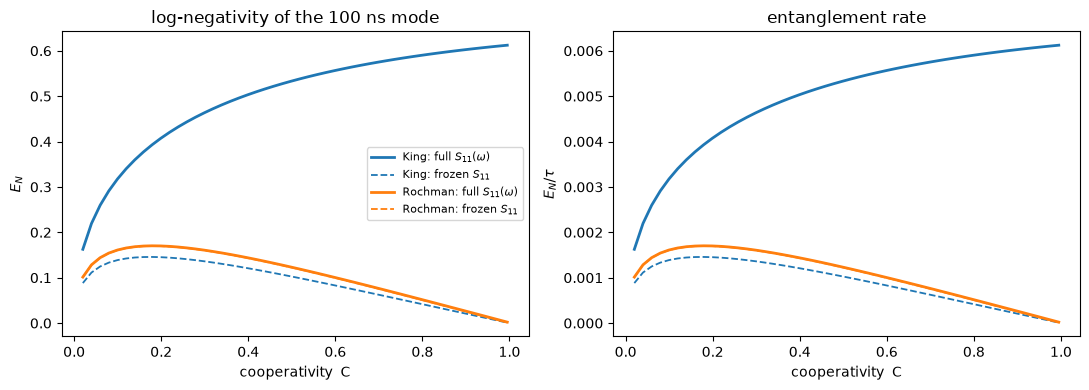

In [5]:
C_list = np.linspace(0.02, 0.995, 50)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

for name, P, col in [("King", KING_PARAMS, "C0"), ("Rochman", ROCHMAN_PARAMS, "C1")]:
    p   = {**P, "eta_a": 1.0, "eta_b": 1.0}
    dev = Transducer.from_params(p, Delta=-p["omega_b"])
    full, frozen = [], []
    for C in C_list:
        g_s = np.sqrt(C * p["kappa_a"] * p["kappa_b"]) / 2
        full.append(log_negativity(covariance_scattering(dev, 0.0, g_s, TAU)))
        frozen.append(log_negativity(covariance_analytic(p, C, TAU, freeze_S11=True)))
    full, frozen = np.array(full), np.array(frozen)
    ax1.plot(C_list, full,   col, lw=2,   label=f"{name}: full $S_{{11}}(\\omega)$")
    ax1.plot(C_list, frozen, col, lw=1.3, ls="--", label=f"{name}: frozen $S_{{11}}$")
    ax2.plot(C_list, full/TAU,   col, lw=2)
    ax2.plot(C_list, frozen/TAU, col, lw=1.3, ls="--")

ax1.set(xlabel="cooperativity  C", ylabel=r"$E_N$", title="log-negativity of the 100 ns mode")
ax2.set(xlabel="cooperativity  C", ylabel=r"$E_N/\tau$", title="entanglement rate")
ax1.legend(fontsize=8)
fig.tight_layout()

## Where the discrepancy comes from

Both models agree exactly on $n_o(\omega)$ and $n_m(\omega)$. They differ only in
$N(\omega)$, the numerator of the correlation $S_{om}(\omega)$:

| | $N(\omega)$ | at threshold |
|---|---|---|
| reference (frozen $S_{11}$) | $(1+C)$ | $E_N \to 0$ for **both** devices |
| full | $(1+C) + 4\omega^2/(\kappa_a\kappa_b)$ | King saturates at $E_N \approx 0.6$; Rochman still $\to 0$ |

Writing $\tilde\nu_- = d - c$ (the two divergent pieces of $d$ and $c$ cancel at $\omega=0$),

$$\tilde\nu_- = \tfrac12
  \;-\; 2\sqrt{C}\!\int |f(\omega)|^2\,
        \frac{(1-\sqrt C)^2 \;+\; 4\omega^2/(\kappa_a\kappa_b)}{\mathrm{denom}(\omega)}\,d\omega .$$

* The $(1-\sqrt C)^2$ term $\to 0$ as $C\to1$ — this is all the frozen model keeps, so it gives $E_N\to0$.
* The $4\omega^2/(\kappa_a\kappa_b)$ term is the $S_{11}(\omega)$ roll-off. It does **not** vanish
  at threshold; its weight is $\sim 1/\mu$ with $\mu = (\kappa_a+\kappa_b)^2/(\kappa_a\kappa_b)$
  (the linewidth-mismatch parameter). Rochman $\mu\approx 6600$ → negligible; King $\mu\approx 6.5$ → $\approx 0.17$.

So the question is purely: **is it legitimate to replace $S_{11}(\omega)$ by its
line-centre value $S_{11}(0)$?** That holds when the temporal-mode bandwidth $1/\tau$ is
well inside the cavity linewidth $(\kappa_a+\kappa_b)/2$ — true for Rochman
($1/\tau = 10\,$MHz $\ll 13\,$GHz), false for King ($1/\tau = 10\,$MHz vs $\sim 10\,$MHz).